<a href="https://colab.research.google.com/github/lena-33/Adult_income_Model/blob/main/Project4_Part_1(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fpath = "/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week09/Data/adult.csv"
df = pd.read_csv(fpath)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


1. What is the target?
- the target is income.
2. What does one row represent?
- A person
3. How many features does the data have?
- 14 features
4. How many rows are in the dataset?
- 48,842 rows
5. What opportunities exist for dimensionality reduction or feature selection with this dataset?
- for dimensionality reduction no need , and for feature selection I am not sure if we need to do any thing.
6. What, if any, challenges do you foresee in cleaning, exploring, or modeling this dataset?
- I noticed a '?' in some rows and I will try to figure out how to solve it.

# Explore/clean the data

In [3]:
df.duplicated().sum()

np.int64(52)

In [4]:
df = df.drop_duplicates()

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


In [7]:
obj_col = df.select_dtypes('object').columns
obj_col

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

In [8]:
for i in obj_col:
  print(df[i].value_counts())

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
?                    2795
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
HS-grad         15770
Some-college    10863
Bachelors        8013
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
9th               756
12th              655
Doctorate         594
5th-6th           507
1st-4th           245
Preschool          81
Name: count, dtype: int64
marital-status
Married-civ-spouse       22366
Never-married            16082
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64
occupation
Prof-specialty       6165
Craft-repair         6102
Exec-managerial      

In [9]:
df.isin(['?']).sum()

,0
age,0
workclass,2795
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,2805
relationship,0
race,0
gender,0


- During data cleaning, missing values were represented by a '?'. I noticed that columns like 'workclass' and 'occupation' already had specific categories like 'Never-worked'. To avoid introducing bias by assuming unknown data means 'never worked', I decided to map the '?' to a distinct category called 'Unknown'. This preserves the data's integrity and allows tree-based models to find potential patterns in the missingness itself.



In [10]:
df.replace("?" , np.nan , inplace=True)
columns_to_fill = ['workclass', 'occupation', 'native-country']

for col in columns_to_fill:
    df[col].fillna('Unknown', inplace=True)

/tmp/ipykernel_3790/2479184561.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


In [11]:
print(df['workclass'].value_counts().head())

workclass
Private             33860
Self-emp-not-inc     3861
Local-gov            3136
Unknown              2795
State-gov            1981
Name: count, dtype: int64


In [12]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48790.000000,4.879000e+04,48790.000000,48790.000000,48790.000000,48790.000000
mean,38.652798,1.896690e+05,10.078807,1080.217688,87.595573,40.425886
std,13.708493,1.056172e+05,2.570046,7455.905921,403.209129,12.392729
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376062e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [13]:
df['capital-gain'].value_counts()

,count
capital-gain,
0,44755
15024,513
7688,410
7298,364
99999,244
...,...
6612,1
1111,1
22040,1


In [14]:
df['capital-loss'].value_counts()

,count
capital-loss,
0,46508
1902,304
1977,253
1887,233
2415,72
...,...
1539,1
2489,1
2080,1


- we can see most people in (capital-gain & capital-loss) have 0 dollar, that mean they do not invest they money(and that is normal for people), that why we see the 25% and 50% and 75% for these two columns is Zero.
 - so we can transfer these columns to binary columns:

1.   if the person invest has money ( > 0) so has value will be ONE
2.   if the person does not invest has money ( = 0) so has value will be ZERO

- we can also notice that the max for capital-gain column is 99999 and it means nan as we learn in previous lessons that this kind of wired number are not real values of the columns, so I will convert it to zero (if I convert it to nan then by using median (0) of the simpleImputer will also the same result).

In [15]:
df['Has_Capital_Gain'] = (df['capital-gain'] > 0).astype(int)
df['Has_Capital_Loss'] = (df['capital-loss'] > 0).astype(int)

In [16]:
df['capital-gain'] = df['capital-gain'].replace(99999, 0)

In [17]:
df.drop(columns=['capital-gain', 'capital-loss'], inplace=True)

In [18]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income,Has_Capital_Gain,Has_Capital_Loss
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K,0,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K,0,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K,0,0
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K,1,0
4,18,Unknown,103497,Some-college,10,Never-married,Unknown,Own-child,White,Female,30,United-States,<=50K,0,0


In [19]:
df['Has_Capital_Gain'].value_counts()

,count
Has_Capital_Gain,
0,44755
1,4035


# Exploratory Visualizations

/tmp/ipykernel_3790/453362151.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette='Set2')


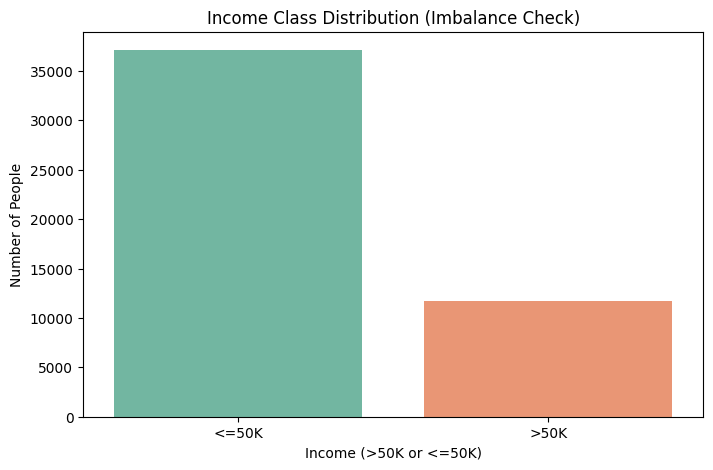

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='income', palette='Set2')
plt.title('Income Class Distribution (Imbalance Check)')
plt.xlabel('Income (>50K or <=50K)')
plt.ylabel('Number of People')
plt.show();

/tmp/ipykernel_3790/3873085183.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='age', palette='Set2')


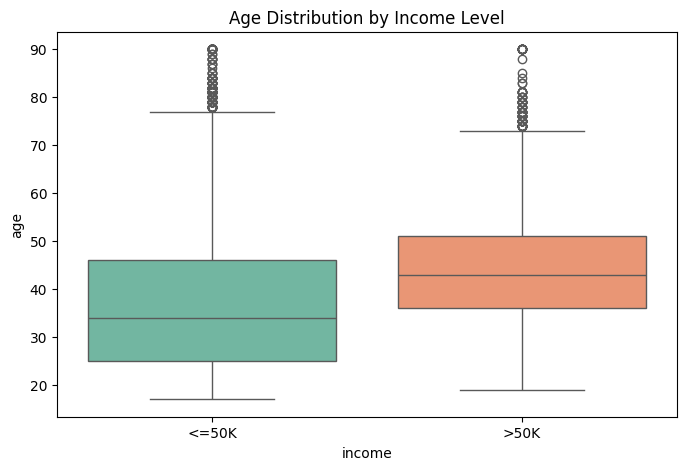

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='age', palette='Set2')
plt.title('Age Distribution by Income Level')
plt.show();

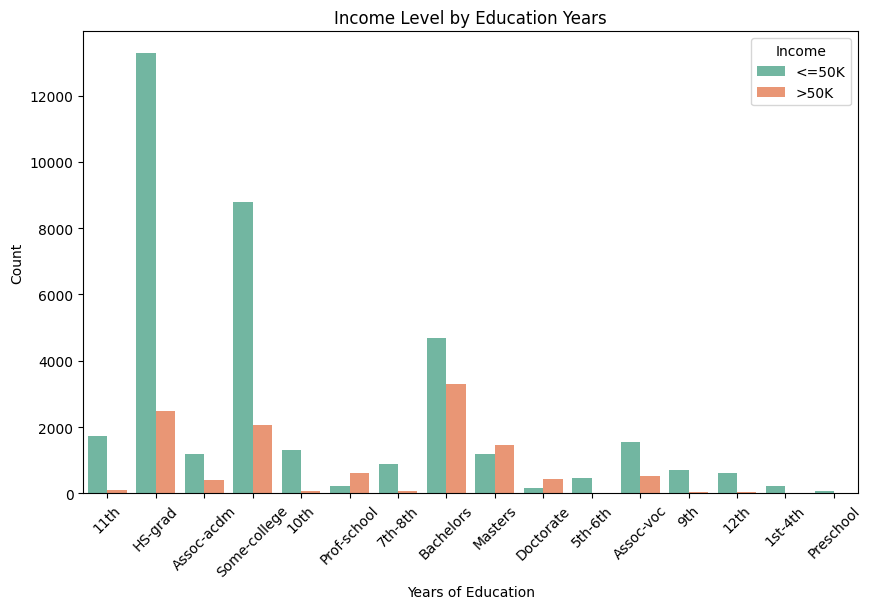

In [45]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='income', palette='Set2')
plt.title('Income Level by Education Years')
plt.xlabel('Years of Education')
plt.ylabel('Count')
plt.legend(title='Income')
plt.xticks(rotation=45)
plt.show()

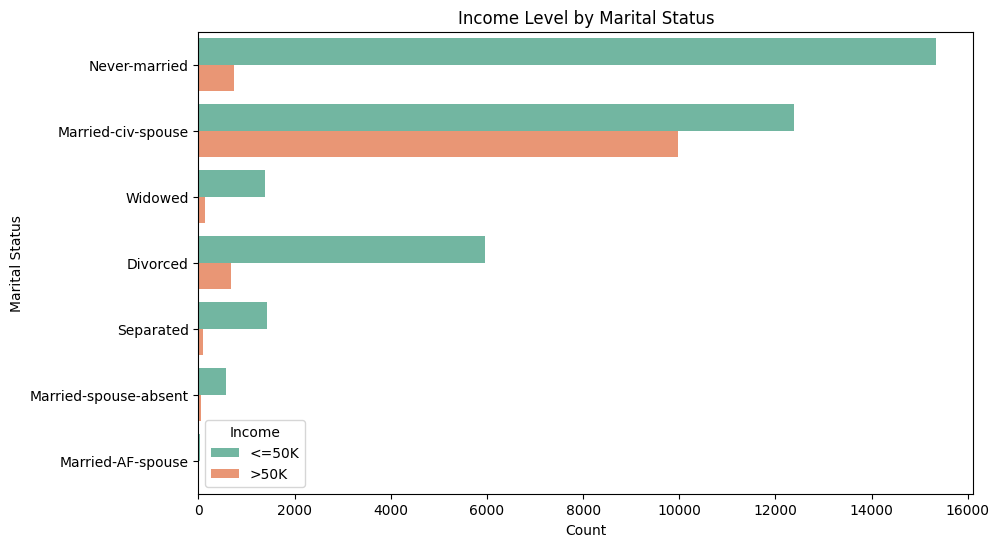

In [23]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='marital-status', hue='income', palette='Set2')
plt.title('Income Level by Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.show()

# Modeling

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline , make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.ensemble import RandomForestClassifier

In [25]:
X = df.drop(columns=['income' , 'education'])
y = df['income']

In [26]:
# Convert income target to numerical values (0 and 1) using direct boolean comparison
y = (y == '>50K').astype(int)
display(y.value_counts())

,count
income,
0,37109
1,11681


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=42)

In [28]:
num_cols = X_train.select_dtypes(include='number').columns
scale = StandardScaler()
num_tuple = ('numircal' , scale, num_cols)
num_tuple

('numircal',
 StandardScaler(),
 Index(['age', 'fnlwgt', 'educational-num', 'hours-per-week',
        'Has_Capital_Gain', 'Has_Capital_Loss'],
       dtype='object'))

In [29]:
cat_cols = X_train.select_dtypes(include='object').columns
cat_encoder = OneHotEncoder(handle_unknown='ignore')
cat_tuple = ('categorical' , cat_encoder, cat_cols)
cat_tuple

('categorical',
 OneHotEncoder(handle_unknown='ignore'),
 Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
        'gender', 'native-country'],
       dtype='object'))

In [30]:
preprocessor = ColumnTransformer([num_tuple, cat_tuple], verbose_feature_names_out=False)
preprocessor

ColumnTransformer(transformers=[('numircal', StandardScaler(),
                                 Index(['age', 'fnlwgt', 'educational-num', 'hours-per-week',
       'Has_Capital_Gain', 'Has_Capital_Loss'],
      dtype='object')),
                                ('categorical',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
       'gender', 'native-country'],
      dtype='object'))],
                  verbose_feature_names_out=False)

In [31]:
X_train_tf = preprocessor.fit_transform(X_train)
X_test_tf = preprocessor.transform(X_test)

In [32]:
y_train.value_counts(1)

,proportion
income,
0,0.760849
1,0.239151


In [33]:
from imblearn.over_sampling import SMOTE,SMOTENC

In [34]:
smote = SMOTE()
X_train_sm , y_train_sm = smote.fit_resample(X_train_tf , y_train)
y_train_sm.value_counts()

,count
income,
0,27841
1,27841


In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    # Get the classification report
    report = classification_report(y_true, y_pred)
    ## Print header and report
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)
    ## CONFUSION MATRICES SUBPLOTS
    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    # create a confusion matrix  of raw counts
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax = axes[0],);
    axes[0].set_title("Raw Counts")
    # create a confusion matrix with the test data
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax = axes[1]);
    axes[1].set_title("Normalized Confusion Matrix")
    # Adjust layout and show figure
    fig.tight_layout()
    plt.show()
    # Return dictionary of classification_report
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict = False,
                            cmap_train='Blues', cmap_test="Reds",colorbar=False):
    # Get predictions for training data
    y_train_pred = model.predict(X_train)
    # Call the helper function to obtain regression metrics for training data
    results_train = classification_metrics(y_train, y_train_pred, #verbose = verbose,
                                     output_dict=True, figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
    print()
    # Get predictions for test data
    y_test_pred = model.predict(X_test)
    # Call the helper function to obtain regression metrics for test data
    results_test = classification_metrics(y_test, y_test_pred, #verbose = verbose,
                                  output_dict=True,figsize=figsize,
                                         colorbar=colorbar, cmap=cmap_test,
                                    label='Test Data' )
    if output_dict == True:
        # Store results in a dataframe if ouput_frame is True
        results_dict = {'train':results_train,
                    'test': results_test}
        return results_dict

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27841
           1       1.00      1.00      1.00     27841

    accuracy                           1.00     55682
   macro avg       1.00      1.00      1.00     55682
weighted avg       1.00      1.00      1.00     55682



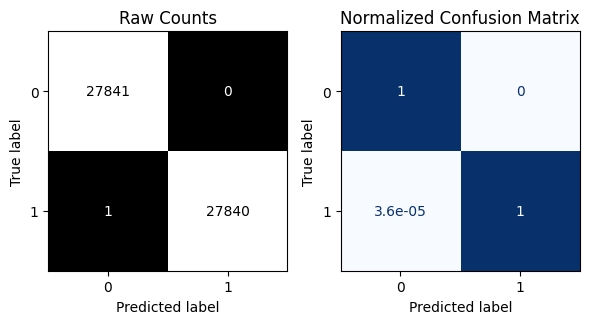


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.89      0.89      9268
           1       0.65      0.66      0.66      2930

    accuracy                           0.83     12198
   macro avg       0.77      0.77      0.77     12198
weighted avg       0.83      0.83      0.83     12198



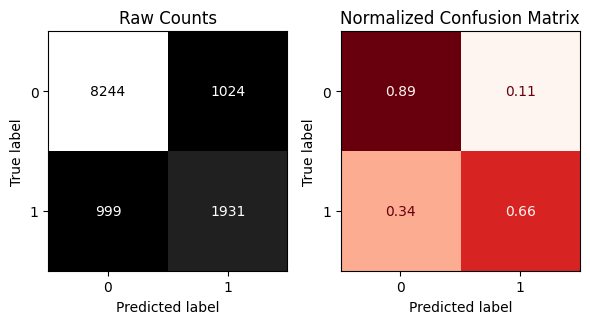

In [36]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_sm, y_train_sm)

evaluate_classification(clf, X_train_sm, y_train_sm, X_test_tf, y_test)

In [38]:
from sklearn.inspection import permutation_importance
feature_names = preprocessor.get_feature_names_out()
r = permutation_importance(clf, X_train_sm.toarray(), y_train_sm, n_repeats=5, random_state=SEED)

In [39]:
perm_importances = pd.Series(r['importances_mean'], index=feature_names,
                           name = 'permutation importance').sort_values(ascending=False)
perm_importances.head(10)

,permutation importance
educational-num,0.140139
age,0.132596
hours-per-week,0.097249
fnlwgt,0.069610
Has_Capital_Gain,0.033512
occupation_Exec-managerial,0.028896
marital-status_Married-civ-spouse,0.022004
relationship_Husband,0.020879
workclass_Private,0.019389
occupation_Prof-specialty,0.019356


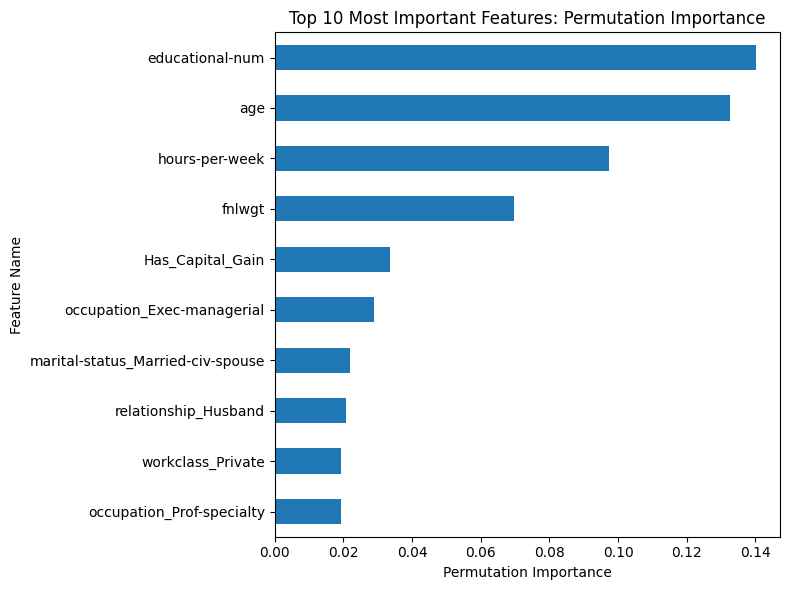

In [46]:
ax = perm_importances.head(10).sort_values().plot(kind='barh',figsize=(8,6))
ax.set(ylabel='Feature Name',xlabel='Permutation Importance',
       title='Top 10 Most Important Features: Permutation Importance');
plt.tight_layout()
plt.show()



The top features influencing income, as revealed by permutation importance, align well with common understanding:

*   Educational-num & Age: Higher education and age (indicating experience) are strong predictors of higher income.
*   Hours-per-week: More hours worked generally correlates with increased earnings.
*   Marital-status_Married-civ-spouse: Being married in a civil spouse relationship often correlates with higher income.
*   Occupation: These high-skill, high-responsibility roles are associated with better pay.
*   Has_Capital_Gain: Presence of capital gains indicates wealth and often higher income.


## Explanatory Visualization

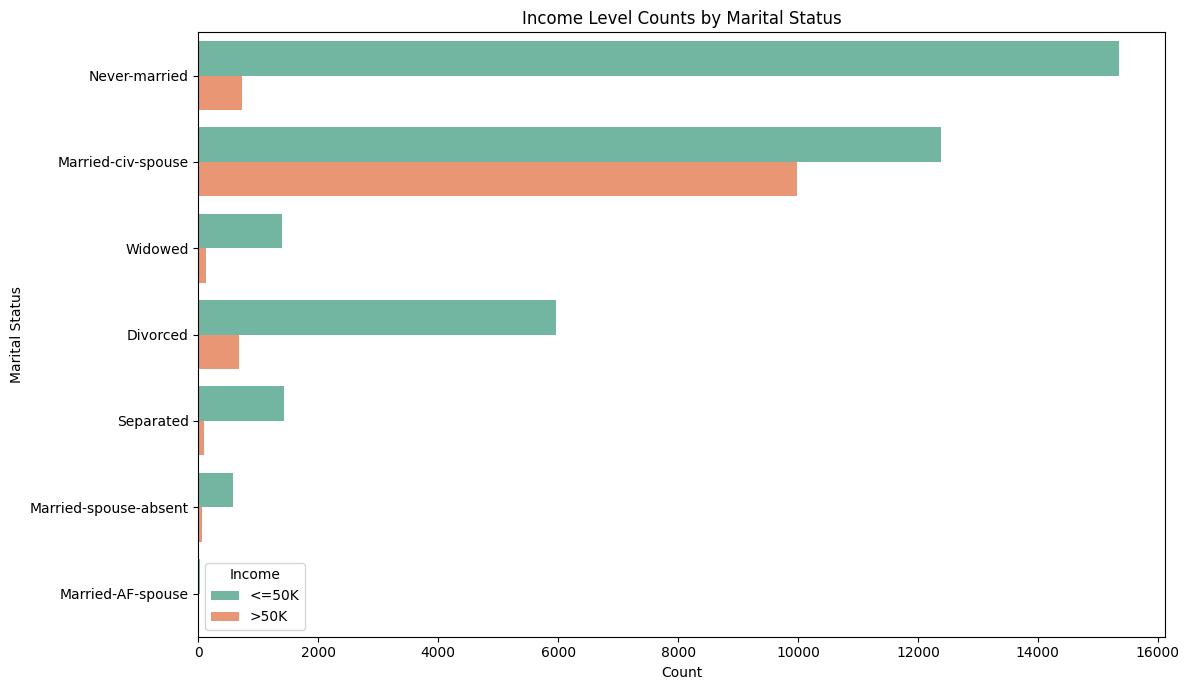

In [51]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, y='marital-status', hue='income', palette='Set2')
plt.title('Income Level Counts by Marital Status')
plt.xlabel('Count')
plt.ylabel('Marital Status')
plt.legend(title='Income')
plt.tight_layout()
plt.show()

### Marital Status and Income

*   Higher Income for Married-civ-spouse: Individuals who are 'Married-civ-spouse' show a significantly higher proportion of earning more than 50K compared to other marital statuses.
*   Lower Income for Other Groups: Groups like 'Never-married', 'Divorced', and 'Separated' have a much larger proportion of individuals earning <=50K.

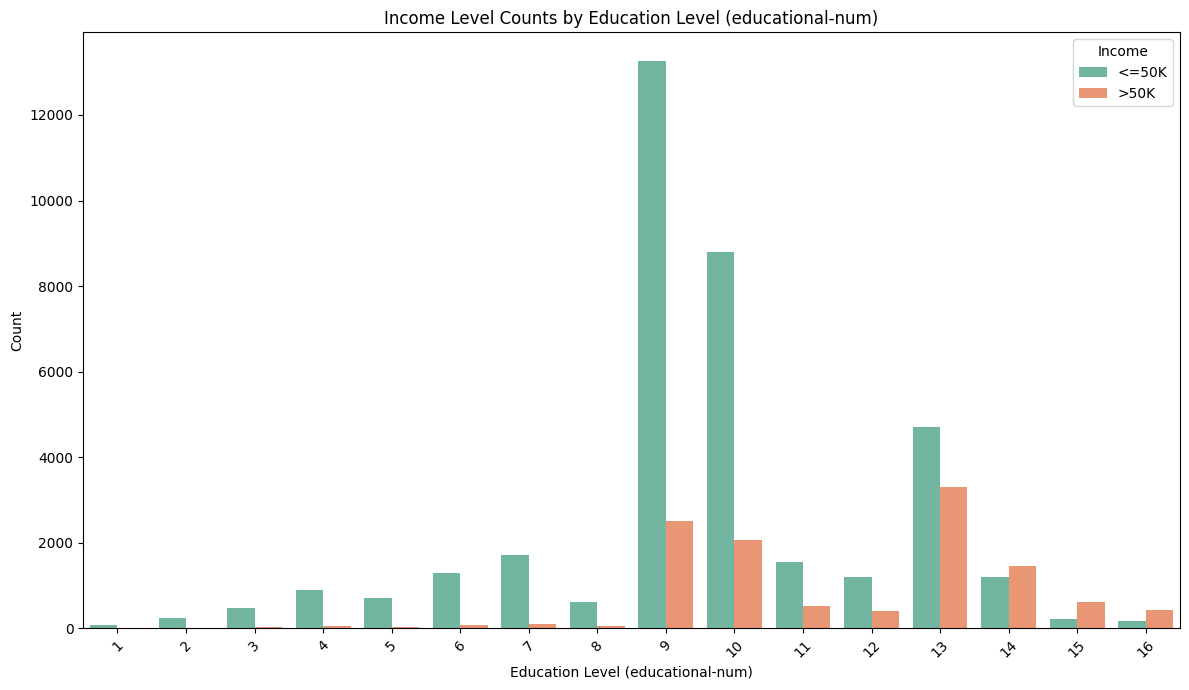

In [55]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df.sort_values('educational-num'), x='educational-num', hue='income', palette='Set2')
plt.title('Income Level Counts by Education Level (educational-num)')
plt.xlabel('Education Level (educational-num)')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Income')
plt.tight_layout()
plt.show()

### Education Level and Income

*   Strong Positive Correlation: There is a clear and strong positive correlation between higher educational attainment (represented by educational-num) and the likelihood of earning >50K.
*   Increased Income with Education: As the educational-num increases, indicating higher levels of education, the proportion of individuals with an income greater than 50K consistently rises.